Problem Name: Search Interest Forecasting for Consumer Demand Planning

ML Task: Time Series Forecasting

Problem Statement:
Brands, media agencies, and market intelligence firms need to anticipate consumer demand 4–8 weeks in advance for campaign planning, inventory decisions, and editorial calendars. Right now, they react to search spikes after they occur. This model predicts Search_Interest for the upcoming week(s) per country-category combination, enabling proactive decisions.

Target (y):
Search_Interest — an existing column (0–100 scale, normalized Google Trends-style score)

Input Features (X):

Feature	Role
Search_Interest (lagged 1–4 weeks)	Core autoregressive signal
Search_Velocity (lagged)	Rate-of-change momentum
Search_Acceleration (lagged)	Second-order momentum
tone_net_sentiment (lagged)	Sentiment leading indicator
Media_Volume (lagged)	Coverage volume as leading signal
Week_Start → week-of-year, month, quarter	Seasonal decomposition
Country_Name, Category	Segment encoding

Feature Engineering:

Lag features: Search_Interest_lag1, _lag2, _lag4 — 1, 2, 4-week lookbacks
Rolling statistics: 4-week rolling mean and std for Search_Interest and Media_Volume
Seasonality flags: Week-of-year encoding (sin/cos transform for cyclicality)
Momentum divergence: Search_Velocity minus its 4-week average to detect breakout weeks
Country-Category embeddings as group-level fixed effects or learned embeddings

Why This Problem:
EDA confirmed Search_Velocity ↔ Search_Acceleration | r = 0.721 — momentum is a real, measurable signal. The dataset has 3.5+ years of weekly data across 14 countries and 3 categories, producing 42 distinct time series. That's enough data volume for per-group forecasting or a global multi-series model. The search interest range of 3–100 with event-driven spikes makes accurate forecasting genuinely challenging and valuable.

Expected ML Output:
A predicted Search_Interest score for the next 1–4 weeks per country-category pair, along with a confidence interval.

Suggested Algorithms:

Facebook Prophet — handles seasonality and holiday effects well; great baseline
LightGBM / XGBoost with lag features — tabular approach, often outperforms classical TS
LSTM / GRU — captures sequential dependencies across the 42 series
SARIMA per group — interpretable statistical baseline for comparison
N-BEATS / PatchTST — modern DL forecasting architectures for portfolio differentiation

Evaluation Metrics:

MAE, RMSE (absolute error on 0–100 scale)
MAPE (percentage error — interpretable for stakeholders)
SMAPE (symmetric version, handles low-interest weeks better)
Directional accuracy (did the model correctly predict up vs. down?)

### 💻 Code Work:

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb


import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### 📤 1. Data Loading (Loading Datafrom Database tables into pandas dataframe df)

In [2]:
# connecting to the MySQL database
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="!@Mstrong@1234",
    database="GDELTTrends"
)

In [3]:
df = pd.read_sql("SELECT * FROM final_master_dataset;", connection)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8022 entries, 0 to 8021
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               8022 non-null   datetime64[ns]
 1   Country_Code             8022 non-null   object        
 2   Country_Name             8022 non-null   object        
 3   Category                 8022 non-null   object        
 4   Search_Interest          8022 non-null   float64       
 5   Search_Velocity          8022 non-null   float64       
 6   Search_Acceleration      8022 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

In [5]:
df['Week_Start'] = pd.to_datetime(df['Week_Start'])

In [6]:
df.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,...,Source_Diversity,Demand_to_Hype_Ratio,Media_Volume_per_Source,Interest_per_Source,Year,Inflation_Rate,Internet_Penetration,GDP_Per_Capita,is_holiday,holiday_count
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62,115.0,1.40110,4.34705,...,81.0,0.579569,1.419753,0.830000,2023,1.63,100.0,49850.69,1,1
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48,52.0,-1.59814,3.93978,...,44.0,1.373208,1.181818,1.654091,2023,1.63,100.0,49850.69,1,1
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46,845.0,1.08379,4.18150,...,329.0,0.087943,2.568389,0.226140,2023,1.63,100.0,49850.69,1,1
3,2023-01-08,AE,United_Arab_Emirates,Fashion_Beauty,65.42,-1.81,11.39,127.0,2.05363,4.35196,...,81.0,0.511094,1.567901,0.807654,2023,1.63,100.0,49850.69,0,0
4,2023-01-08,AE,United_Arab_Emirates,Fitness_Wearables,70.28,-2.50,-8.47,32.0,2.88533,4.90696,...,15.0,2.129697,2.133333,4.685333,2023,1.63,100.0,49850.69,0,0


In [7]:
# Number of time series
series_count = df.groupby(["Country_Name", "Category"])

print("Number of time series:", len(series_count))

Number of time series: 42


In [8]:
cat_cols = df.select_dtypes(include=object).columns.to_list()
num_cols = df.select_dtypes(include=['int64','float64']).columns.to_list()
print("Category columns:",cat_cols)
print("Numerical columns:",num_cols)

Category columns: ['Country_Code', 'Country_Name', 'Category']
Numerical columns: ['Search_Interest', 'Search_Velocity', 'Search_Acceleration', 'Media_Volume', 'tone_net_sentiment', 'tone_positive_score', 'tone_negative_score', 'tone_polarity', 'tone_activity_density', 'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio', 'Media_Volume_per_Source', 'Interest_per_Source', 'Year', 'Inflation_Rate', 'Internet_Penetration', 'GDP_Per_Capita', 'is_holiday', 'holiday_count']


### 2. EDA

#### 2.1 Univariate Analysis

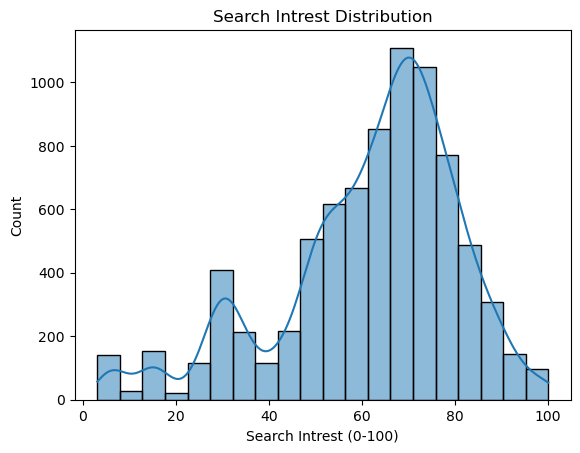

In [9]:
# performing univariate analysis on Search Intrest(target columns)
plt.Figure(figsize=(6,4))
sns.histplot(df['Search_Interest'],kde=True, bins =20)
plt.title('Search Intrest Distribution')
plt.xlabel('Search Intrest (0-100)')
plt.show()

In [10]:
display(df['Search_Interest'].describe())

count    8022.000000
mean       61.828077
std        19.176093
min         3.160000
25%        52.292500
50%        65.880000
75%        74.660000
max       100.000000
Name: Search_Interest, dtype: float64

#### from the above Search Intrest is slight left skew (negative skew)

### 2.2 Multivariate Analysis: Time Series Decomposition


Selected Representative Series:
Country='India', 
Category='Fashion_Beauty'


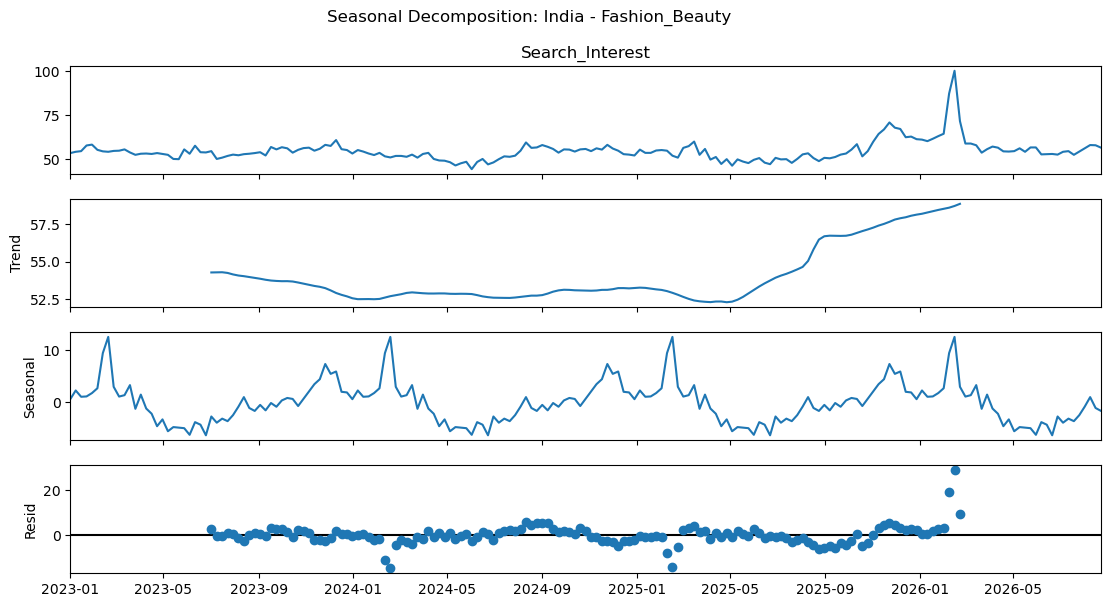

In [11]:
#  select the series with the maximum available data points

target_country = "India"
target_category = "Fashion_Beauty"

print(f"\nSelected Representative Series:\nCountry='{target_country}', \nCategory='{target_category}'")

# 3. Filter the dataframe for this specific series
sample_df = (df[(df['Country_Name'] == target_country) & (df['Category'] == target_category)].set_index('Week_Start')['Search_Interest'].asfreq('W-SUN'))  # Ensures explicit Sunday weekly frequency)

# 4. Perform Decomposition
decomposition = seasonal_decompose(sample_df.interpolate(method='linear'), model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(12, 6)
plt.suptitle(f'Seasonal Decomposition: {target_country} - {target_category}', y=1.02)
plt.show()

### Multivariate Analysis: Feature Correlation Matrix

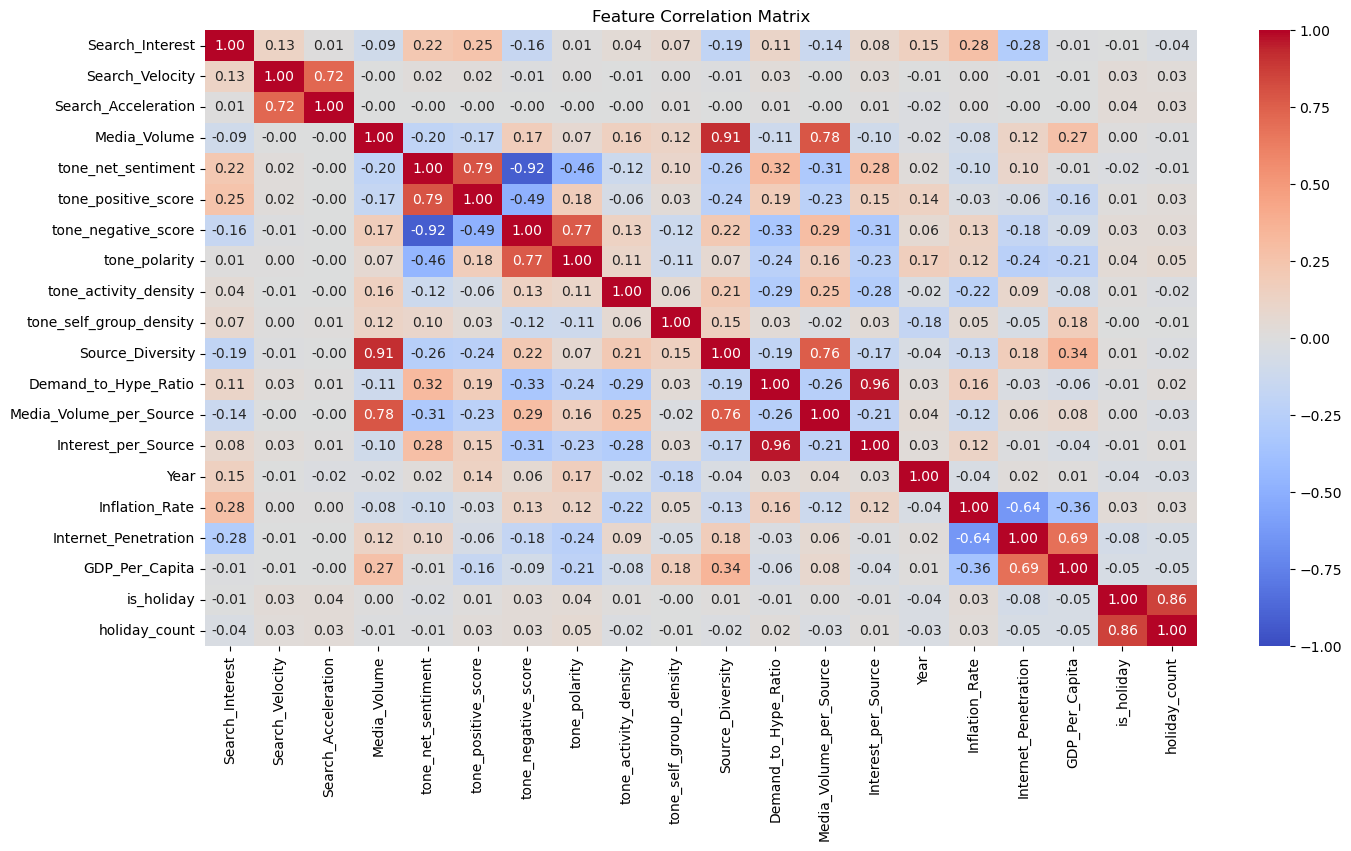

In [12]:
numerical_cols = num_cols
plt.figure(figsize=(16, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

### 👩🏻‍💻 3. Modeling
#### 🛠️ 3.1 Pre-Requisites

#### 🔄 3.1.1 Missing Values Identification and Handling 

In [13]:
print("--- Missing Values Count per Column ---")
display(df.isnull().sum()[df.isnull().sum() > 0])

--- Missing Values Count per Column ---


Media_Volume               297
tone_net_sentiment         297
tone_positive_score        297
tone_negative_score        297
tone_polarity              297
tone_activity_density      297
tone_self_group_density    297
Source_Diversity           297
Demand_to_Hype_Ratio       297
Media_Volume_per_Source    297
Interest_per_Source        297
dtype: int64

In [14]:
# In GDELT dataset these columns are absent so replacing them with 0
zero_fill_cols = ["Media_Volume","Source_Diversity","Media_Volume_per_Source","Interest_per_Source"]
for col in zero_fill_cols:
    df[col] = df[col].fillna(0)

### Assumption
### Though there is no Media_volume but sentiment doesn't change it remain the previous value untill new Media_volume is seen

In [15]:
df.loc[df['tone_self_group_density'].isnull(), 'Week_Start']

384    2025-06-15
385    2025-06-15
386    2025-06-15
387    2025-06-22
388    2025-06-22
          ...    
7835   2025-06-15
7836   2025-06-22
7837   2025-06-22
7838   2025-06-22
7840   2025-06-29
Name: Week_Start, Length: 297, dtype: datetime64[ns]

In [16]:
ffill_cols = ["tone_net_sentiment","tone_positive_score","tone_negative_score","tone_polarity","tone_activity_density","tone_self_group_density"]
#  ffill grouped by series to avoid cross-series data bleed
for col in ffill_cols:
    df[col] = df.groupby(['Country_Name', 'Category'])[col].transform(lambda x: x.ffill().bfill())

In [17]:
(df.isnull().sum()[df.isnull().sum() >0])

Demand_to_Hype_Ratio    297
dtype: int64

In [18]:
df.loc[df['tone_self_group_density'].isnull(), 'Week_Start']


Series([], Name: Week_Start, dtype: datetime64[ns])

### Demand_to_Hype_Ratio is not required for this project dropping the column

In [19]:
df= df.drop(columns=['Demand_to_Hype_Ratio'])

In [20]:
(df.isnull().sum()[df.isnull().sum() >0])

Series([], dtype: int64)

### All Null values are handled

### 3.1.2 **Stationarity Check (Augmented Dickey-Fuller Test)**

In [21]:
# Function to run ADF test on a given series
def is_series_stationary(series):
    clean_series = series.dropna()
    if len(clean_series) < 20:
        return False
    # p-value < 0.05 means data is stationary
    p_value = adfuller(clean_series)[1]
    return p_value < 0.05

stationary_counts = 0
non_stationary_counts = 0

# Loop through each of the 42 Country-Category groups directly
for (country, category), group in df.groupby(['Country_Code', 'Category']):
    if is_series_stationary(group['Search_Interest']):
        stationary_counts += 1
    else:
        non_stationary_counts += 1

print(f"Stationarity Test Results for 'Search_Interest':")
print(f"  - Stationary Series:     {stationary_counts} / 42")
print(f"  - Non-Stationary Series: {non_stationary_counts} / 42")

Stationarity Test Results for 'Search_Interest':
  - Stationary Series:     21 / 42
  - Non-Stationary Series: 21 / 42


### ⚙️ 3.1.3 **Feature Engineering**
##### We use ['Country_Code', 'Category'] for grouping.

In [22]:
df.columns

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity',
       'Media_Volume_per_Source', 'Interest_per_Source', 'Year',
       'Inflation_Rate', 'Internet_Penetration', 'GDP_Per_Capita',
       'is_holiday', 'holiday_count'],
      dtype='object')

In [23]:
# Ensure dataframe is properly sorted before computing temporal features
df = df.sort_values(by=['Country_Name', 'Category', 'Week_Start']).reset_index(drop=True)

# Lag Features (1, 2, and 4 weeks) for Search_Intrest and Media_Volume
for lag in [1, 2, 4]:
    df[f'Search_Interest_lag_{lag}'] = df.groupby(['Country_Name', 'Category'])['Search_Interest'].shift(lag)

In [24]:
# Search_velocity and search_acceleration Lag
df['Search_Velocity_lag'] = df.groupby(['Country_Name', 'Category'])['Search_Velocity'].shift(1)
df['Search_Acceleration_lag'] = df.groupby(['Country_Name','Category'])['Search_Acceleration'].shift(1)

In [25]:
# Rolling Statistics (4-week windows)
df['Search_Interest_roll_mean_4w'] = df.groupby(['Country_Name', 'Category'])['Search_Interest'].transform(lambda x: x.shift(1).rolling(4).mean())
df['Search_Interest_roll_std_4w'] = df.groupby(['Country_Name', 'Category'])['Search_Interest'].transform(lambda x: x.shift(1).rolling(4).std())
df['Media_Volume_roll_mean_4w'] = df.groupby(['Country_Name', 'Category'])['Media_Volume'].transform(lambda x: x.shift(1).rolling(4).mean())

In [26]:
week_of_year = df['Week_Start'].dt.isocalendar().week
df['sin_week'] = np.sin(2 * np.pi * week_of_year / 52)
df['cos_week'] = np.cos(2 * np.pi * week_of_year / 52)

### Drop rows with NaN values created by initial 4-week lookbacks

In [27]:
null_count= (df.isnull().sum()[df.isnull().sum() > 0])
max_null_count = null_count[max(null_count.to_dict(),key=null_count.get)]

In [28]:
print("length of new data frame after removing null values will be: ",len(df) - max_null_count)

length of new data frame after removing null values will be:  7854


In [29]:
df_model = df.dropna().copy().reset_index(drop=True)

In [30]:
df_model.describe()

,Week_Start,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,...,Search_Interest_lag_1,Search_Interest_lag_2,Search_Interest_lag_4,Search_Velocity_lag,Search_Acceleration_lag,Search_Interest_roll_mean_4w,Search_Interest_roll_std_4w,Media_Volume_roll_mean_4w,sin_week,cos_week
count,7854,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,...,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.000000,7854.0,7854.0
mean,2024-11-10 00:00:00,61.782931,-0.015896,-0.009621,4785.977846,-0.205729,3.430303,3.636032,7.066336,20.916876,...,61.798827,61.805103,61.829101,-0.006276,0.001505,61.811479,3.082789,4800.294531,0.063292,-0.056072
min,2023-01-29 00:00:00,3.160000,-51.680000,-90.690000,0.000000,-9.980800,0.218818,0.000000,1.162790,11.392400,...,3.160000,3.160000,3.160000,-51.680000,-90.690000,4.397500,0.085000,0.000000,-1.0,-1.0
25%,2023-12-17 00:00:00,52.282500,-2.090000,-3.060000,37.000000,-1.433680,2.957450,2.867208,6.387395,19.900775,...,52.282500,52.292500,52.282500,-2.087500,-3.047500,52.652500,1.316943,41.000000,-0.663123,-0.748511
50%,2024-11-10 00:00:00,65.870000,-0.110000,0.130000,244.500000,-0.303746,3.253340,3.684890,7.096190,20.979800,...,65.870000,65.875000,65.880000,-0.110000,0.140000,66.375000,2.223172,260.750000,0.120537,-0.120537
75%,2025-10-05 00:00:00,74.610000,2.000000,3.270000,1808.000000,0.786168,3.783260,4.488505,7.724312,22.156350,...,74.627500,74.637500,74.660000,2.000000,3.280000,74.691250,3.751503,1838.562500,0.748511,0.663123
max,2026-08-23 00:00:00,100.000000,42.020000,44.140000,168862.000000,10.319000,11.155700,11.802400,13.924100,31.606500,...,100.000000,100.000000,100.000000,42.020000,44.140000,97.260000,37.997453,163215.500000,1.0,1.0
std,NaN,19.127331,4.834587,6.962177,17959.273784,1.729455,0.783819,1.215648,1.092397,2.025922,...,19.134905,19.138222,19.168071,4.826997,6.955925,18.788419,2.941261,17913.736822,0.703234,0.706002


### removing columns that are not necessary for the model

In [31]:
# Removing unnnecesay columns and PREVENTING DATA LEAKAGE
unnecessary_cols = ['Country_Code','tone_positive_score','tone_negative_score', 'tone_polarity', 
                    'tone_activity_density','tone_self_group_density', 'Source_Diversity',
                    'Media_Volume_per_Source', 'Interest_per_Source', 'Year', 
                    'Internet_Penetration','is_holiday']

# CRITICAL FIX: Drop contemporaneous features to prevent target leakage!
# We can't use these at time 't' to predict 't'
leakage_cols = ['Search_Velocity', 'Search_Acceleration', 'Media_Volume', 'tone_net_sentiment']

df_model = df_model.drop(columns=unnecessary_cols + leakage_cols)

In [32]:
# Encode Categorical Variables for LightGBM
# LightGBM handles categoricals well if converted to 'category' dtype
df_model['Country_Name'] = df_model['Country_Name'].astype('category')
df_model['Category'] = df_model['Category'].astype('category')

print(df_model.dtypes)

Week_Start                      datetime64[ns]
Country_Name                          category
Category                              category
Search_Interest                        float64
Inflation_Rate                         float64
GDP_Per_Capita                         float64
holiday_count                            int64
Search_Interest_lag_1                  float64
Search_Interest_lag_2                  float64
Search_Interest_lag_4                  float64
Search_Velocity_lag                    float64
Search_Acceleration_lag                float64
Search_Interest_roll_mean_4w           float64
Search_Interest_roll_std_4w            float64
Media_Volume_roll_mean_4w              float64
sin_week                               Float64
cos_week                               Float64
dtype: object


#### 🎯 3.1.4 X & y data preparation:

In [33]:
# Chronological Train / Val / Test Split
# Sort chronologically
df_model = df_model.sort_values('Week_Start').reset_index(drop=True)

# Split dynamically based on dates present in dataset
val_start = '2025-01-01'
test_start = '2025-09-01'

train_df = df_model[df_model['Week_Start'] < val_start]
val_df = df_model[(df_model['Week_Start'] >= val_start) & (df_model['Week_Start'] < test_start)]
test_df = df_model[df_model['Week_Start'] >= test_start]


target = 'Search_Interest'
features = [col for col in df_model.columns if col not in ['Week_Start', target]]

X_train, y_train = train_df[features], train_df[target]
X_val, y_val = val_df[features], val_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")


Train size: 4242 | Val size: 1470 | Test size: 2142


### 🤖 3.2 Model + Define, Train & Study

In [34]:
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'verbose': -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

Training until validation scores don't improve for 50 rounds
[50]	training's l1: 2.54286	valid_1's l1: 2.67134
[100]	training's l1: 1.90076	valid_1's l1: 2.40246
[150]	training's l1: 1.71193	valid_1's l1: 2.38122
[200]	training's l1: 1.57325	valid_1's l1: 2.37836
[250]	training's l1: 1.45131	valid_1's l1: 2.36865
[300]	training's l1: 1.34442	valid_1's l1: 2.3733
Early stopping, best iteration is:
[255]	training's l1: 1.43877	valid_1's l1: 2.36666


### ✅ 3.3 Trained Model Predictions & Evaluations

In [35]:
# Define helper to compute metrics and diagnose fit
from sklearn.metrics import mean_squared_error, r2_score
def evaluate_model(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    
    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2 = r2_score(y_test_true, y_test_pred)
    
    # Fit Diagnosis Rule
    r2_gap = train_r2 - test_r2
    if train_r2 < 0.5 and test_r2 < 0.5:
        fit_status = "Underfit"
    elif r2_gap > 0.15:
        fit_status = "Overfit"
    else:
        fit_status = "Well-Fit"
        
    return {
        "Models": model_name,
        "TrainLoss (RMSE)": round(train_rmse, 2),
        "TestLoss (RMSE)": round(test_rmse, 2),
        "TrainScore (R²)": round(train_r2, 2),
        "TestScore (R²)": round(test_r2, 2),
        "Bias-Variance (Fit)": fit_status
    }

results = []

# -------------------------------------------------------------
# LightGBM Evaluation
# -------------------------------------------------------------
lgb_train_pred = model.predict(X_train, num_iteration=model.best_iteration)
lgb_test_pred = model.predict(X_test, num_iteration=model.best_iteration)

results.append(evaluate_model("LightGBM (Tuned)", y_train, lgb_train_pred, y_test, lgb_test_pred))



# -------------------------------------------------------------
#  Display Results Summary Table
# -------------------------------------------------------------
results_df = pd.DataFrame(results)

# Format and display formatted table
display(results_df.style.hide(axis="index"))

Models,TrainLoss (RMSE),TestLoss (RMSE),TrainScore (R²),TestScore (R²),Bias-Variance (Fit)
LightGBM (Tuned),1.960000,7.230000,0.990000,0.840000,Well-Fit


#### 📥 3.5 Saving model & Real Time Prediction

In [36]:
folder_path = r"E:\\ML Project Internship\\ML-Project\\app\pickles\\"
os.makedirs(folder_path, exist_ok=True)

model_file   = os.path.join(folder_path, "lightgbm_search_Intrest_forecast_model.pkl")
joblib.dump(model, model_file)
# Extract and Save Metadata & Schema
metadata = {
    'features': features,
    'categorical_features': ['Country_Name', 'Category'],
    'categorical_categories': {
        'Country_Name': df_model['Country_Name'].cat.categories.tolist(),
        'Category': df_model['Category'].cat.categories.tolist()
    },
    'target': target
}

metadata_file = os.path.join(folder_path, 'lightgbm_search_Intrest_forecast_model_metadata.pkl')
joblib.dump(metadata, metadata_file)

print(f" Saved model to: {model_file}")
print(f" Saved metadata to: {metadata_file}")

 Saved model to: E:\\ML Project Internship\\ML-Project\\app\pickles\\lightgbm_search_Intrest_forecast_model.pkl
 Saved metadata to: E:\\ML Project Internship\\ML-Project\\app\pickles\\lightgbm_search_Intrest_forecast_model_metadata.pkl


In [37]:
# Load Saved Artifacts
model_path = "E://ML Project Internship//ML-Project//app//pickles//lightgbm_search_Intrest_forecast_model.pkl"
metadata_path = "E://ML Project Internship//ML-Project//app//pickles//lightgbm_search_Intrest_forecast_model_metadata.pkl"

loaded_model = joblib.load(model_path)
metadata = joblib.load(metadata_path)

In [39]:
# 2. Out-of-Sample Forecasting Function (With Missing Features Fix)
def generate_forecast(df_raw, target_country, target_category, horizon_weeks=4):
    """
    Extracts recent history for a given country-category, dynamically projects 
    lags/rolling features step-by-step into the future, and yields predicted values.
    """
    # Filter and sort data for chosen time series
    series_df = df_raw[
        (df_raw['Country_Name'] == target_country) & 
        (df_raw['Category'] == target_category)
    ].sort_values('Week_Start').copy().reset_index(drop=True)

    if len(series_df) < 4:
        raise ValueError("Minimum 4 historical weeks required for feature engineering.")

    # Track historical search values
    history_dates = list(series_df['Week_Start'])
    history_values = list(series_df['Search_Interest'])
    
    forecast_dates = []
    forecast_values = []
    
    last_date = history_dates[-1]
    latest_row = series_df.iloc[-1]  # Reference row for static country/macro features

    # Recursive / Iterative forecasting loop
    for w in range(1, horizon_weeks + 1):
        next_date = last_date + pd.Timedelta(weeks=w)
        forecast_dates.append(next_date)
        
        # Combine actual history and newly predicted values
        combined_values = history_values + forecast_values
        
        # Build vector for required model features dynamically
        feat_dict = {
            'Country_Name': target_country,
            'Category': target_category,
            'Search_Interest_lag_1': combined_values[-1],
            'Search_Interest_lag_2': combined_values[-2] if len(combined_values) >= 2 else combined_values[-1],
            'Search_Interest_lag_4': combined_values[-4] if len(combined_values) >= 4 else combined_values[-1],
            'Search_Interest_roll_mean_4w': np.mean(combined_values[-4:]),
            'Search_Interest_roll_std_4w': np.std(combined_values[-4:]),
            'sin_week': np.sin(2 * np.pi * next_date.isocalendar().week / 52),
            'cos_week': np.cos(2 * np.pi * next_date.isocalendar().week / 52)
        }

        # Dynamically pull macro/lagged features that were present during training
        for col in metadata['features']:
            if col not in feat_dict:
                if col in series_df.columns:
                    # Carry forward the most recent value from historical dataset
                    feat_dict[col] = latest_row[col]
                else:
                    # Fill with 0 as safe fallback if column isn't in raw dataset
                    feat_dict[col] = 0

        # Construct DataFrame matching model schema
        input_df = pd.DataFrame([feat_dict])
        
        # Set categorical types matching training categories
        for col in metadata['categorical_features']:
            if col in metadata['categorical_categories']:
                categories = metadata['categorical_categories'][col]
                input_df[col] = pd.Categorical(input_df[col], categories=categories)
            else:
                input_df[col] = input_df[col].astype('category')
            
        # Reorder columns to match exact feature order expected by LightGBM
        input_df = input_df[metadata['features']]
        
        # Predict & clamp output to Google Trends scale (0 - 100)
        pred = loaded_model.predict(input_df)[0]
        pred_clamped = np.clip(pred, 0, 100)
        
        forecast_values.append(pred_clamped)

    # Return structured historical and forecast DataFrames
    df_hist = pd.DataFrame({'Week_Start': history_dates, 'Search_Interest': history_values, 'Type': 'Historical'})
    df_fore = pd.DataFrame({'Week_Start': forecast_dates, 'Search_Interest': forecast_values, 'Type': 'Forecast'})
    
    return df_hist, df_fore

# %%
# 3. Generate Forecast & Test
country = "India"
category = "Fashion_Beauty"

df_hist, df_fore = generate_forecast(df, target_country=country, target_category=category, horizon_weeks=4)

print(f"--- 🔮 4-Week Forecast: {country} | {category} ---")
display(df_fore[['Week_Start', 'Search_Interest']])

--- 🔮 4-Week Forecast: India | Fashion_Beauty ---


,Week_Start,Search_Interest
0,2026-08-30,56.739851
1,2026-09-06,57.114580
2,2026-09-13,57.054894
3,2026-09-20,56.474127
